In [7]:
# !pip install numpy pandas seaborn scikit-learn
# !pip install --upgrade pip

In [8]:
import numpy as np
import pandas as pd

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14

In [10]:
from sklearn.model_selection import train_test_split  # делим данные на train/test
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    MinMaxScaler,
    OneHotEncoder,
    PolynomialFeatures,
)
from sklearn.compose import ColumnTransformer  # конвейер для разных типов признаков
from sklearn.impute import SimpleImputer  # заполнение пропусков
from sklearn.pipeline import Pipeline  # сборка последовательности шагов
from sklearn.linear_model import LinearRegression  # простая модель
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display
import joblib
from sklearn.linear_model import Lasso, Ridge

np.random.seed(42)

In [11]:
data_path = "train.csv"
df = pd.read_csv(data_path, sep=',', decimal=',')

target_name = "milk_yield_kg"

df.head(10)

,cow_id,milk_yield_kg,feed_energy_eke,feed_crude_protein_g,sugar_protein_ratio,breed,pasture_type,sire_breed,milk_fat_pct,milk_protein_pct,milk_taste_label,age_group
0,488,6005,13.5,1842,0.94,РефлешнСоверинг,Равнинное,Айдиал,3.62,3.073,не вкусно,более_2_лет
1,422,5982,13.8,1722,0.89,РефлешнСоверинг,Холмистое,Айдиал,3.61,3.073,не вкусно,более_2_лет
2,105,5700,14.4,1934,0.885,Вис Бик Айдиал,Равнинное,Соверин,3.57,3.079,вкусно,более_2_лет
3,115,5412,12.1,1924,0.89,Вис Бик Айдиал,Равнинное,Соверин,3.57,3.071,не вкусно,менее_2_лет
4,350,6171,15.3,1966,0.94,РефлешнСоверинг,Равнинное,Соверин,3.73,3.076,вкусно,более_2_лет
5,278,6112,14.6,1988,0.93,РефлешнСоверинг,Холмистое,Соверин,3.73,3.075,не вкусно,более_2_лет
6,506,6460,15.3,1680,0.93,Вис Бик Айдиал,Равнинное,Айдиал,3.73,3.075,вкусно,более_2_лет
7,211,6723,16.4,1894,0.94,Вис Бик Айдиал,Равнинное,Айдиал,3.72,3.074,вкусно,более_2_лет
8,444,5450,14.4,1782,0.88,РефлешнСоверинг,Равнинное,Айдиал,3.21,3.078,вкусно,менее_2_лет
9,527,5734,15.3,1780,0.88,РефлешнСоверинг,Равнинное,Соверин,3.63,3.072,вкусно,более_2_лет


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   cow_id                507 non-null    int64 
 1   milk_yield_kg         507 non-null    int64 
 2   feed_energy_eke       507 non-null    object
 3   feed_crude_protein_g  507 non-null    int64 
 4   sugar_protein_ratio   507 non-null    object
 5   breed                 507 non-null    object
 6   pasture_type          507 non-null    object
 7   sire_breed            507 non-null    object
 8   milk_fat_pct          507 non-null    object
 9   milk_protein_pct      507 non-null    object
 10  milk_taste_label      507 non-null    object
 11  age_group             507 non-null    object
dtypes: int64(3), object(9)
memory usage: 47.7+ KB


In [13]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cow_id,507.0,NaN,NaN,NaN,319.187377,182.571548,1.0,160.5,320.0,477.5,629.0
milk_yield_kg,507.0,NaN,NaN,NaN,6197.42998,1814.353749,5204.0,5752.5,6130.0,6487.0,45616.0
feed_energy_eke,507,54,14.6,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
feed_crude_protein_g,507.0,NaN,NaN,NaN,1919.360947,180.863546,1660.0,1769.0,1877.0,2051.5,2349.0
sugar_protein_ratio,507,12,0.94,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
breed,507,2,Вис Бик Айдиал,297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pasture_type,507,3,Холмистое,282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sire_breed,507,3,Соверин,257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
milk_fat_pct,507,47,3.72,88,NaN,NaN,NaN,NaN,NaN,NaN,NaN
milk_protein_pct,507,15,3.076,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
emissionMilk = 10000
df = df[df['milk_yield_kg'] < emissionMilk]

<Axes: xlabel='milk_yield_kg', ylabel='Count'>

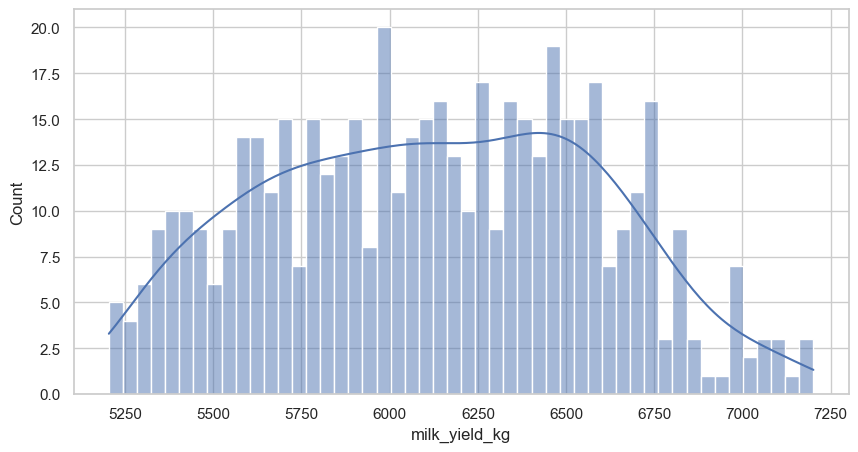

In [15]:
sns.histplot(data=df, x="milk_yield_kg", kde=True, bins=50)

<Axes: xlabel='milk_yield_kg'>

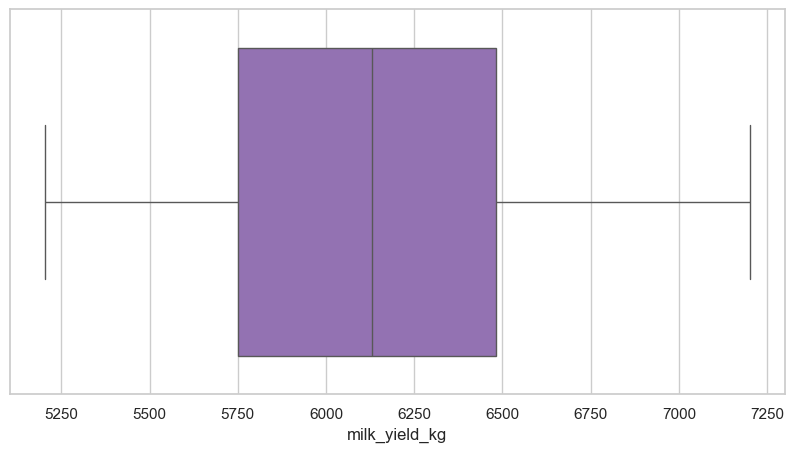

In [16]:
sns.boxplot(x=df["milk_yield_kg"], color="tab:purple")

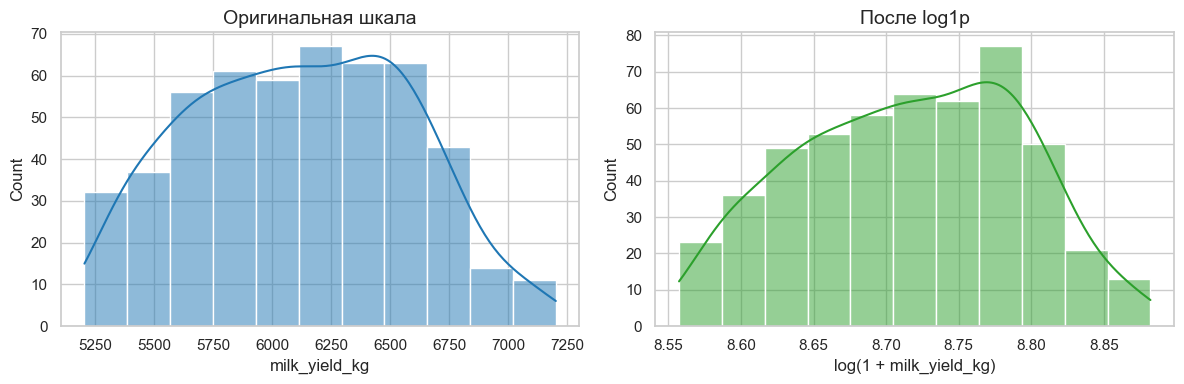

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[target_name], ax=axes[0], kde=True, color="tab:blue")
axes[0].set_title("Оригинальная шкала")
axes[0].set_xlabel(target_name)

sns.histplot(np.log1p(df[target_name]), ax=axes[1], kde=True, color="tab:green")
axes[1].set_title("После log1p")
axes[1].set_xlabel("log(1 + milk_yield_kg)")

plt.tight_layout()
plt.show()

<Axes: xlabel='feed_energy_eke', ylabel='Count'>

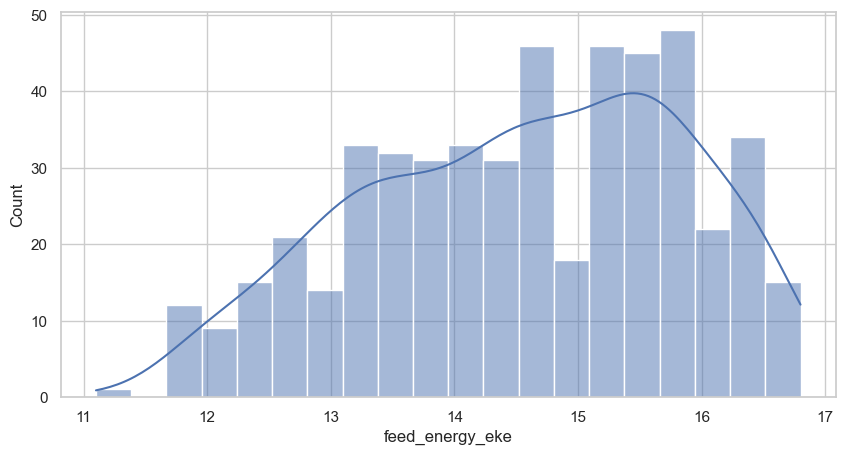

In [18]:
df["feed_energy_eke"] = pd.to_numeric(df["feed_energy_eke"], errors="coerce")

sns.histplot(data=df, x="feed_energy_eke", kde=True, bins=20)

<Axes: xlabel='feed_energy_eke'>

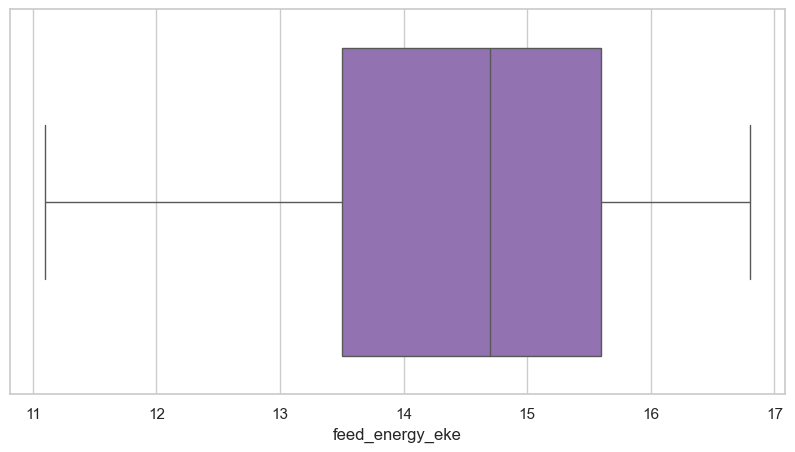

In [19]:
sns.boxplot(x=df["feed_energy_eke"], color="tab:purple")

<Axes: xlabel='feed_crude_protein_g', ylabel='Count'>

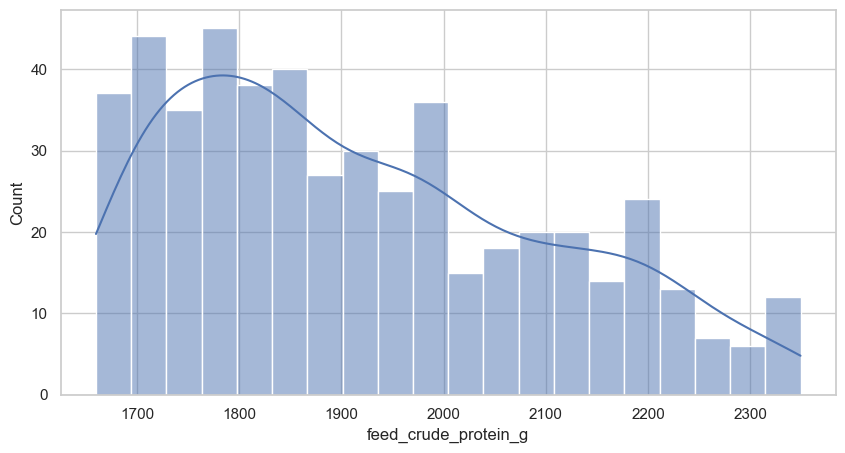

In [20]:
sns.histplot(data=df, x="feed_crude_protein_g", kde=True, bins=20)

<Axes: xlabel='feed_crude_protein_g'>

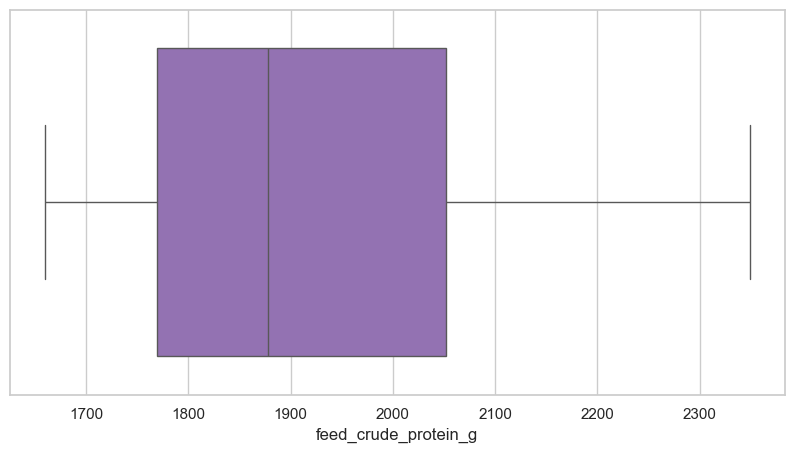

In [21]:
sns.boxplot(x=df["feed_crude_protein_g"], color="tab:purple")

<Axes: xlabel='sugar_protein_ratio', ylabel='Count'>

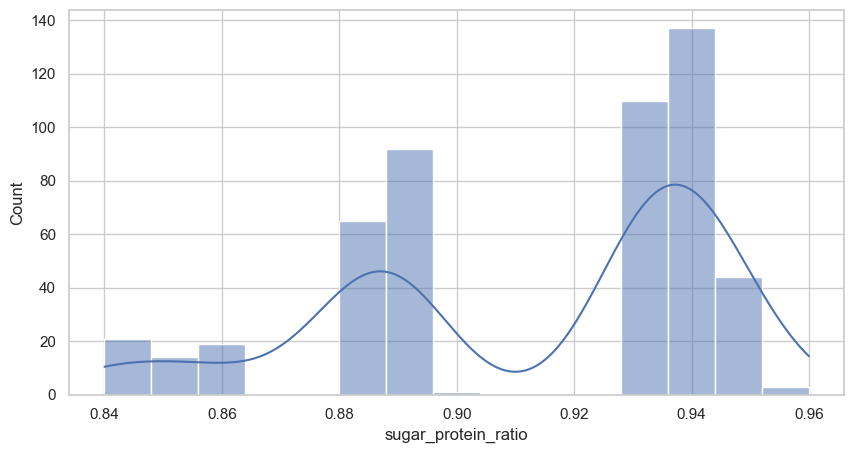

In [22]:
df["sugar_protein_ratio"] = pd.to_numeric(df["sugar_protein_ratio"], errors="coerce")
sns.histplot(data=df, x="sugar_protein_ratio", kde=True, bins=15)

<Axes: xlabel='sugar_protein_ratio'>

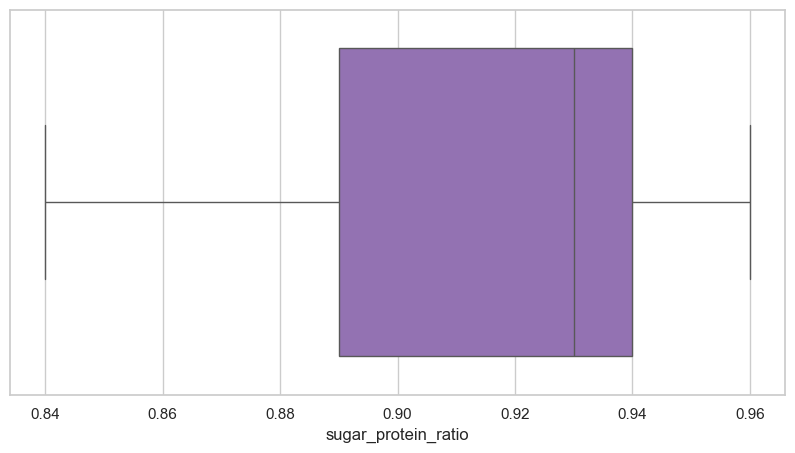

In [23]:
sns.boxplot(x=df["sugar_protein_ratio"], color="tab:purple")

<Axes: xlabel='milk_fat_pct', ylabel='Count'>

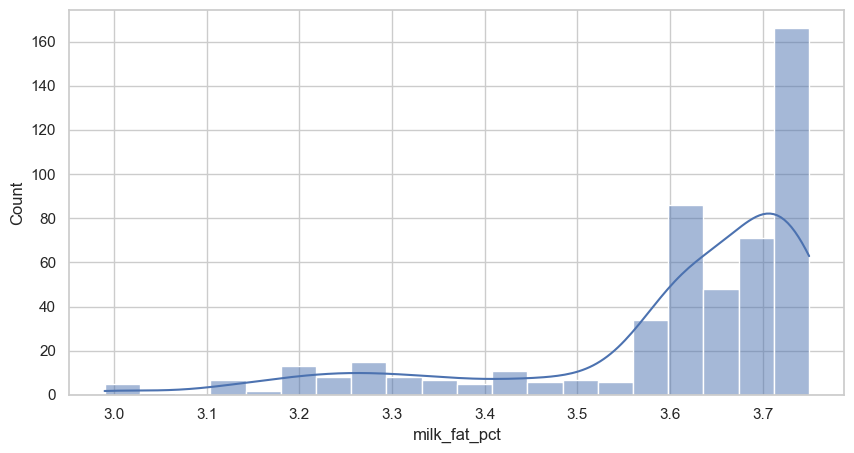

In [24]:
df["milk_fat_pct"] = pd.to_numeric(df["milk_fat_pct"], errors="coerce")

sns.histplot(data=df, x="milk_fat_pct", kde=True, bins=20)

<Axes: xlabel='milk_fat_pct'>

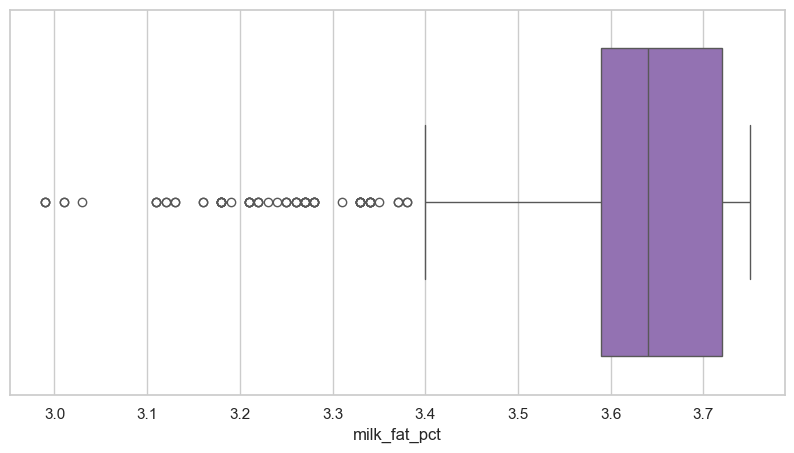

In [25]:
sns.boxplot(x=df["milk_fat_pct"], color="tab:purple")

<Axes: xlabel='milk_protein_pct', ylabel='Count'>

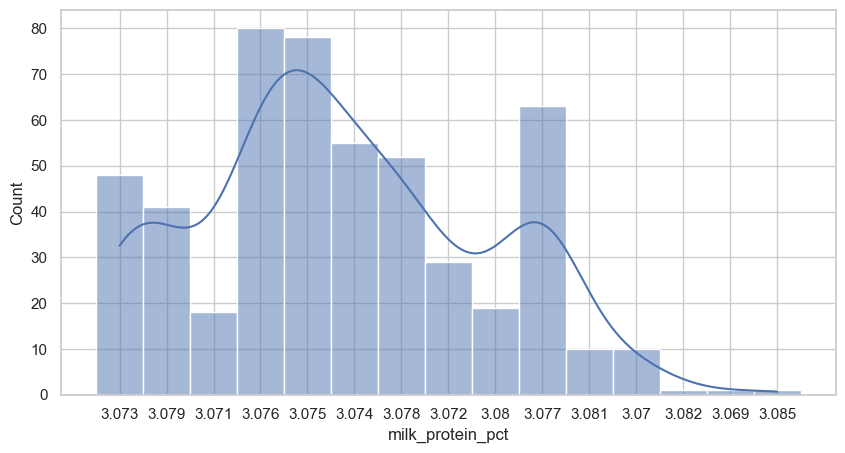

In [26]:
sns.histplot(data=df, x="milk_protein_pct", kde=True, bins=20)

<Axes: xlabel='milk_protein_pct'>

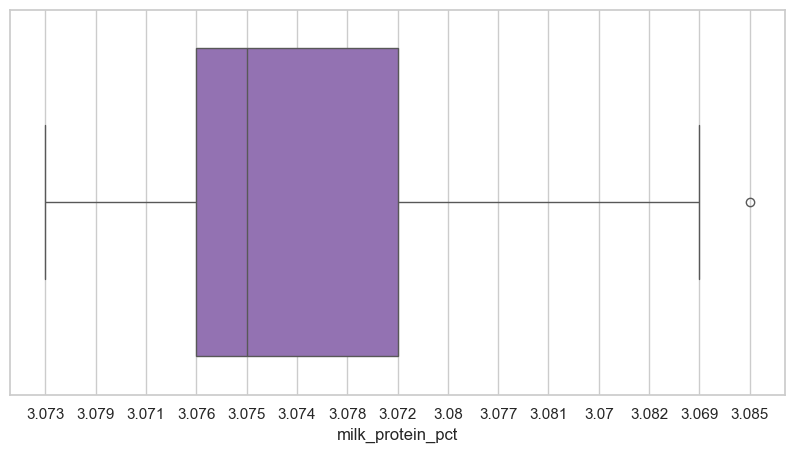

In [27]:
sns.boxplot(x=df["milk_protein_pct"], color="tab:purple")

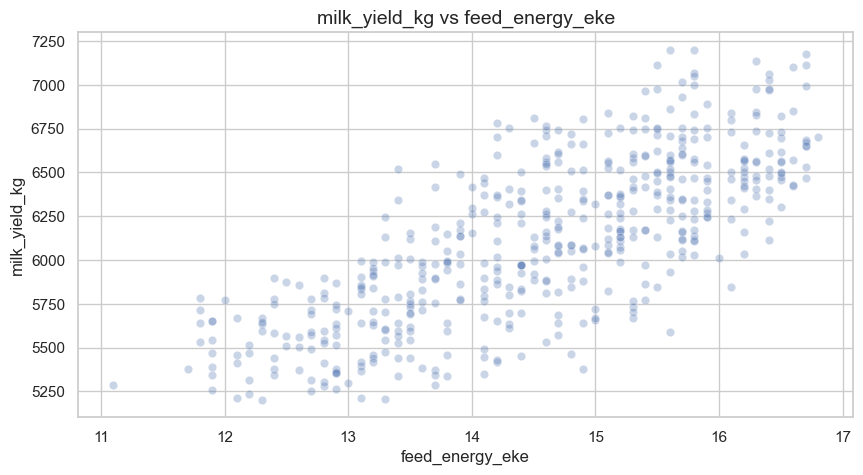

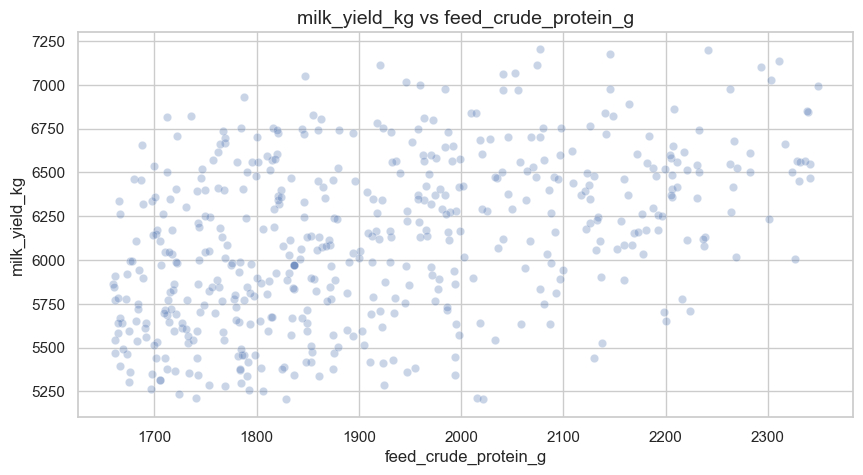

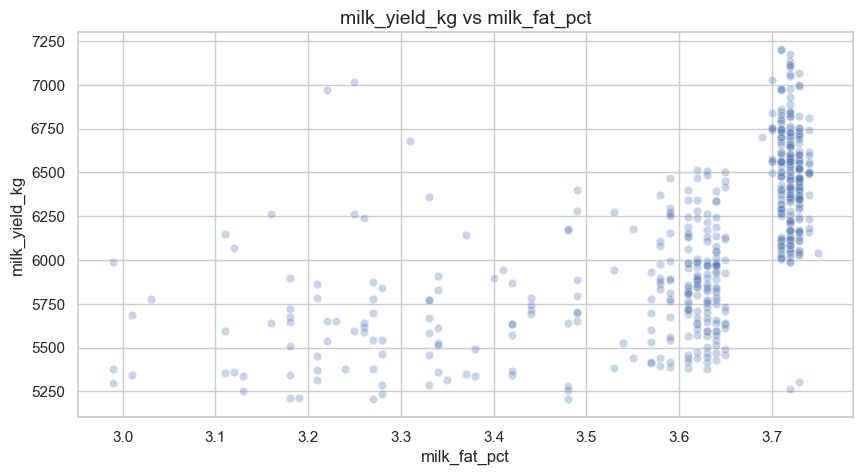

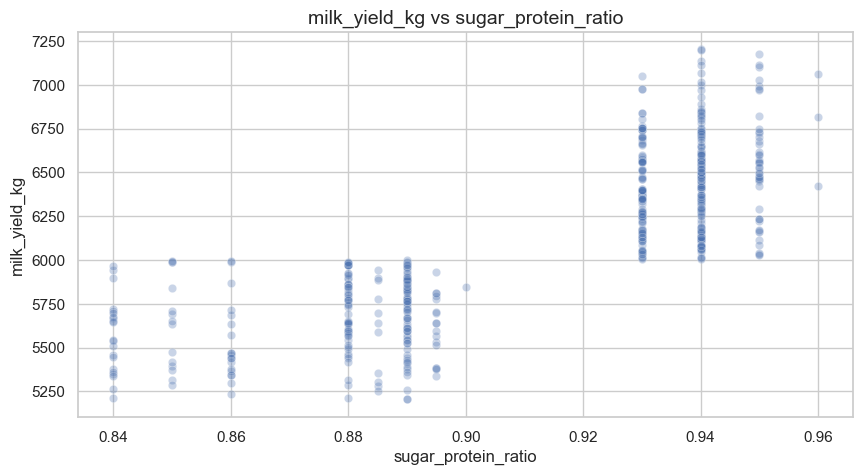

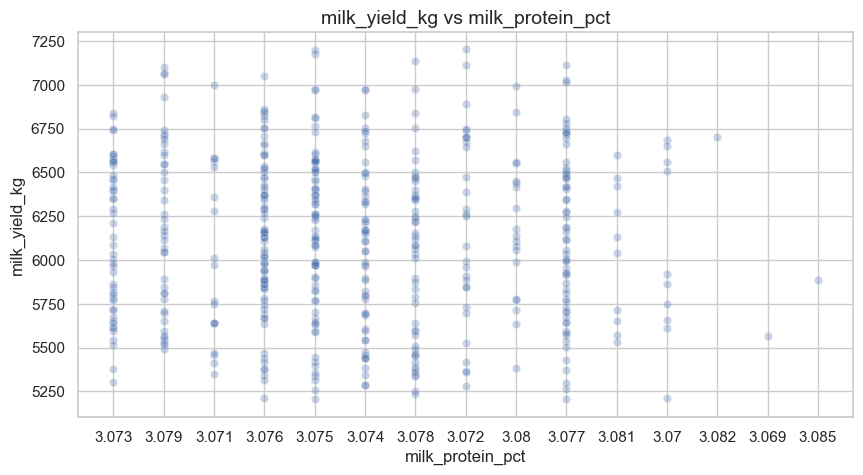

In [28]:
cols_to_plot = ['feed_energy_eke', 'feed_crude_protein_g', 'milk_fat_pct', 'sugar_protein_ratio', 'milk_protein_pct']
for col in cols_to_plot:
    sns.scatterplot(data=df, x=col, y='milk_yield_kg', alpha=0.3)
    plt.title(f"milk_yield_kg vs {col}")
    plt.xlabel(col)
    plt.ylabel("milk_yield_kg")
    plt.show()

In [29]:
cols_to_convert = ['feed_energy_eke', 'sugar_protein_ratio', 'milk_fat_pct', 'milk_protein_pct']
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 506 entries, 0 to 506
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cow_id                506 non-null    int64  
 1   milk_yield_kg         506 non-null    int64  
 2   feed_energy_eke       506 non-null    float64
 3   feed_crude_protein_g  506 non-null    int64  
 4   sugar_protein_ratio   506 non-null    float64
 5   breed                 506 non-null    object 
 6   pasture_type          506 non-null    object 
 7   sire_breed            506 non-null    object 
 8   milk_fat_pct          506 non-null    float64
 9   milk_protein_pct      506 non-null    float64
 10  milk_taste_label      506 non-null    object 
 11  age_group             506 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 51.4+ KB


In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cow_id,506.0,319.784585,182.255840,1.000,161.250,321.000,477.750,629.000
milk_yield_kg,506.0,6119.527668,464.153824,5204.000,5751.750,6129.500,6481.500,7201.000
feed_energy_eke,506.0,14.558300,1.283274,11.100,13.500,14.700,15.600,16.800
feed_crude_protein_g,506.0,1919.843874,180.715030,1660.000,1769.000,1878.000,2052.250,2349.000
sugar_protein_ratio,506.0,0.912569,0.032459,0.840,0.890,0.930,0.940,0.960
milk_fat_pct,506.0,3.603854,0.169093,2.990,3.590,3.640,3.720,3.750
milk_protein_pct,506.0,3.075656,0.002558,3.069,3.074,3.076,3.077,3.085


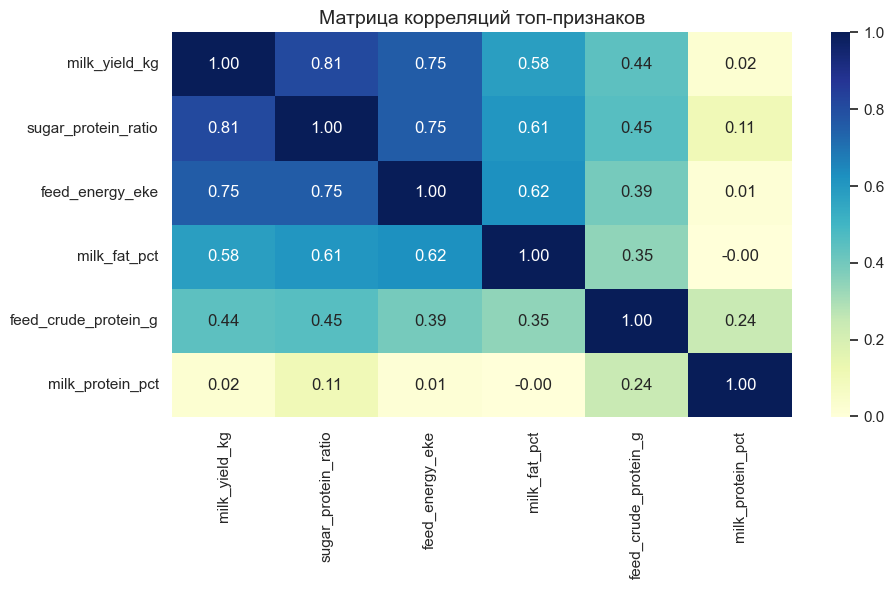

In [32]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()

top_features = corr_matrix["milk_yield_kg"].abs().sort_values(ascending=False).head(6).index

sns.heatmap(corr_matrix.loc[top_features, top_features], annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Матрица корреляций топ-признаков")
plt.show()

In [33]:
X = df.drop(columns=[target_name])
y = df[target_name]

In [34]:
X = df.drop(['cow_id', target_name], axis=1)
y = df[target_name]

In [35]:
print(f"Размер X (признаки): {X.shape}")
print(f"Размер y (цель): {y.shape}")
print()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Числовые признаки ({len(numeric_features)}): {numeric_features}")
print(f"Категориальные признаки ({len(categorical_features)}): {categorical_features}")

Размер X (признаки): (506, 10)
Размер y (цель): (506,)

Числовые признаки (5): ['feed_energy_eke', 'feed_crude_protein_g', 'sugar_protein_ratio', 'milk_fat_pct', 'milk_protein_pct']
Категориальные признаки (5): ['breed', 'pasture_type', 'sire_breed', 'milk_taste_label', 'age_group']


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер валидационной выборки: {X_test.shape[0]} строк")

Размер обучающей выборки: 404 строк
Размер валидационной выборки: 102 строк


In [37]:
# !pip install category_encoders

- SimpleImputer заменяет пропуски в категориальных признаках

In [38]:
import category_encoders as ce

numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target_encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, numeric_features),
        ("cat", categorical_preprocess, categorical_features),
    ],
    remainder="drop",
)

preprocess_with_poly = Pipeline(steps=[
    ("preprocess", preprocess),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
])

model = Pipeline(steps= [
    ("preprocess_with_poly", preprocess_with_poly),
    ("regressor", Ridge(alpha=5.0, max_iter=10000)),
])

model.fit(X_train, y_train)

,steps,"[('preprocess_with_poly', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('preprocess', ...), ('poly', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [39]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R^2 : {r2:.3f}")

MAE : 135.286
RMSE: 174.312
R^2 : 0.872


---

In [40]:
test_path = "test.csv"
df_test = pd.read_csv(test_path, sep=',', decimal='.')
df_test.head()

,cow_id,feed_energy_eke,feed_crude_protein_g,sugar_protein_ratio,breed,pasture_type,sire_breed,milk_fat_pct,milk_protein_pct,milk_taste_label,age_group
0,397,15.0,1739,0.93,РефлешнСоверинг,Холмистое,Соверин,3.72,3.077,не вкусно,более_2_лет
1,249,16.3,2258,0.94,Вис Бик Айдиал,Равнинное,Айдиал,3.73,3.079,не вкусно,более_2_лет
2,216,12.7,1687,0.86,Вис Бик Айдиал,Холмистое,Айдиал,3.42,3.076,не вкусно,более_2_лет
3,354,14.8,1835,0.93,РефлешнСоверинг,Равнинное,Соверин,3.71,3.072,не вкусно,более_2_лет
4,549,14.8,1727,0.93,Вис Бик Айдиал,Холмистое,Айдиал,3.72,3.074,не вкусно,более_2_лет


In [41]:
test_cow_ids = df_test['cow_id'].copy()

X_test_kaggle = df_test.drop(['cow_id'], axis=1)


predictions = model.predict(X_test_kaggle)

In [42]:
submission = pd.DataFrame({
    "cow_id": test_cow_ids,
    "milk_yield_prediction": predictions,
})

In [43]:
submission.head()

,cow_id,milk_yield_prediction
0,397,6202.477348
1,249,6734.886923
2,216,5792.297891
3,354,6164.946814
4,549,6557.402123


In [44]:
submission_path = "result.csv"
submission.to_csv(submission_path, index=False)
print(f"Saved baseline submission to {submission_path}")

Saved baseline submission to result.csv
